# Task 2: Neural Network

1. Introduction
2. Part A — Dataset Understanding
3. Part B — Data Preprocessing
4. Part C — Building the Neural Network
5. Part D — Activation Functions
6. Part E — Training
7. Part F — Evaluation
8. Part G — Experimentation
9. Final Insights
10. Conclusion

In [25]:
# Import required libraries

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [26]:
# Load the MNIST dataset

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


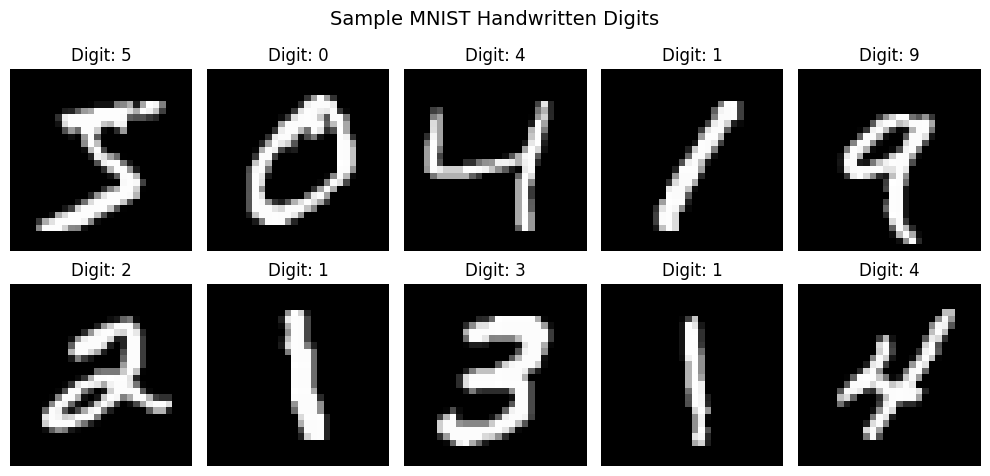

In [27]:
# Display sample MNIST images

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray", interpolation="nearest")
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")

plt.suptitle("Sample MNIST Handwritten Digits", fontsize=14)
plt.tight_layout()
plt.show()

## Part B — Data Preprocessing

Before training the neural network, the MNIST images need to be preprocessed.
The pixel values in the original images range from 0 to 255.

In [28]:
# Check the range of pixel values

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0
Maximum pixel value: 255


In [29]:
# Normalize pixel values from 0-255 to 0-1

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Minimum pixel value after normalization:", X_train.min())
print("Maximum pixel value after normalization:", X_train.max())

Minimum pixel value after normalization: 0.0
Maximum pixel value after normalization: 1.0


In [30]:
# Flatten each 28x28 image into a 784-element vector

X_train_flat = X_train.reshape(X_train.shape[0], 784)
X_test_flat = X_test.reshape(X_test.shape[0], 784)

print("Training data shape after flattening:", X_train_flat.shape)
print("Testing data shape after flattening:", X_test_flat.shape)

Training data shape after flattening: (60000, 784)
Testing data shape after flattening: (10000, 784)


In [31]:
print("Training samples:", X_train_flat.shape[0])
print("Testing samples:", X_test_flat.shape[0])
print("Features per image:", X_train_flat.shape[1])
print("Number of classes:", len(np.unique(y_train)))

Training samples: 60000
Testing samples: 10000
Features per image: 784
Number of classes: 10


## Part C — Building the Neural Network

A simple feedforward neural network is used to classify the handwritten digits.

The network consists of:
- An input layer with 784 input features
- A hidden layer with 128 neurons using ReLU activation
- An output layer with 10 neurons using Softmax activation

In [32]:
# Build the neural network

model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# Display the model architecture
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## Part D — Activation Functions

### ReLU

ReLU stands for Rectified Linear Unit. It is used in the hidden layer of our neural network.

The ReLU function is:

ReLU(x) = max(0, x)

It converts negative values to 0 while keeping positive values unchanged.
ReLU is commonly used in hidden layers because it is simple and helps the network learn non-linear patterns.

### Softmax

Softmax is used in the output layer because this is a multi-class classification problem with 10 possible classes (digits 0 to 9).

Softmax converts the output values into probabilities whose sum is approximately 1. The class with the highest probability is selected as the predicted digit.

In our model:
- ReLU is used in the hidden layer.
- Softmax is used in the output layer.

In [33]:
# Compile the neural network

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


## Part E — Training

The neural network is trained using the training dataset. A validation split is used to monitor how the model performs on data that is not used directly for updating the model weights.

In [34]:
# Train the neural network

history = model.fit(
    X_train_flat,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8941 - loss: 0.3853 - val_accuracy: 0.9547 - val_loss: 0.1757
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9511 - loss: 0.1738 - val_accuracy: 0.9672 - val_loss: 0.1271
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9637 - loss: 0.1251 - val_accuracy: 0.9705 - val_loss: 0.1036
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9719 - loss: 0.0975 - val_accuracy: 0.9735 - val_loss: 0.0951
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9772 - loss: 0.0782 - val_accuracy: 0.9762 - val_loss: 0.0859
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9816 - loss: 0.0648 - val_accuracy: 0.9782 - val_loss: 0.0823
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9841 - loss: 0.0544 - val_accuracy: 0.9768 - val_loss: 0.0791
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9870 - loss: 0.0457 - val_accuracy: 0.

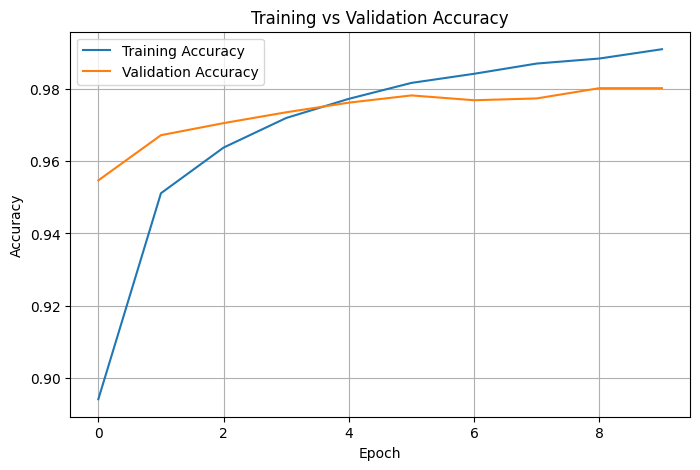

In [35]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

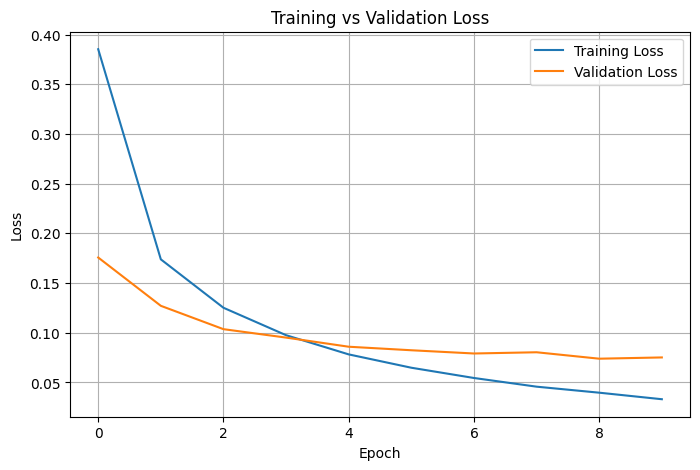

In [36]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [37]:
# Evaluate the model on the test dataset

test_loss, test_accuracy = model.evaluate(
    X_test_flat,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.07624246180057526
Test Accuracy: 0.9768000245094299


## Part F — Evaluation

The trained model is evaluated on the test dataset. We will calculate the test accuracy and examine the confusion matrix to understand which digits are classified correctly or incorrectly.

In [38]:
# Generate predictions for the test dataset

y_pred_prob = model.predict(X_test_flat)

# Convert probabilities into predicted class labels
y_pred = np.argmax(y_pred_prob, axis=1)

print("Predictions generated successfully.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predictions generated successfully.


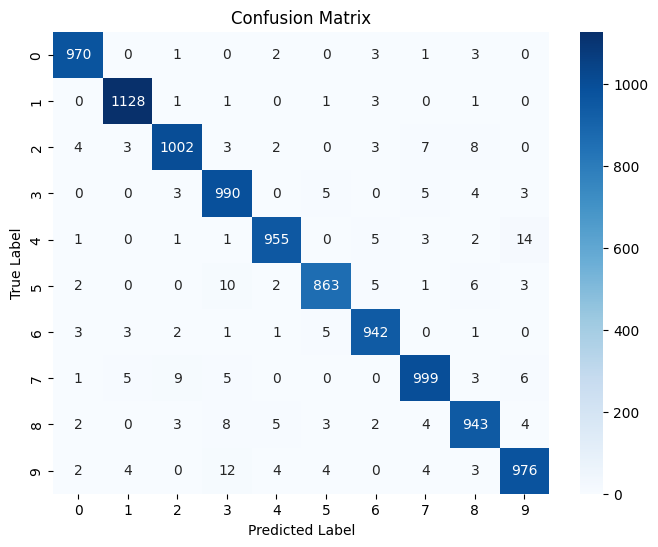

In [39]:
# Create the confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [40]:
# Classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.97      0.98       982
           5       0.98      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.97      1028
           8       0.97      0.97      0.97       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



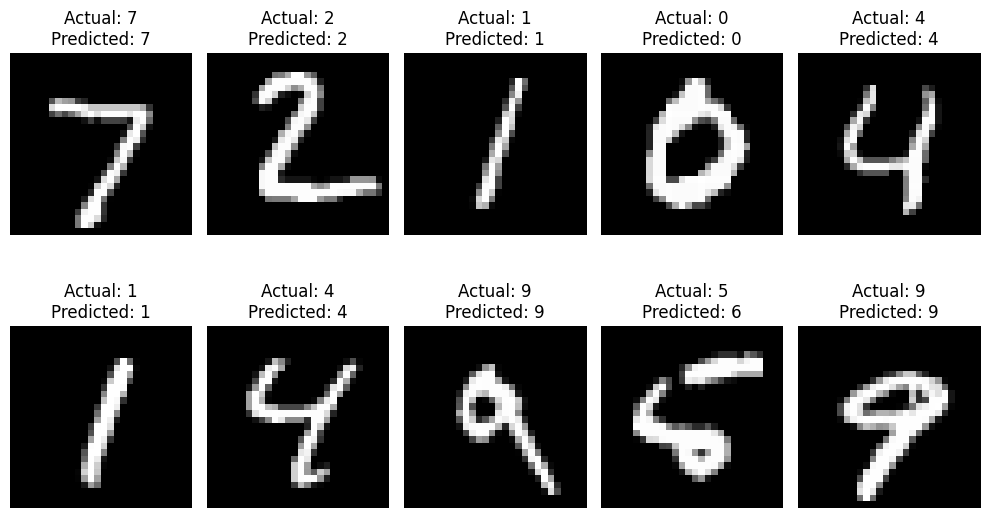

In [41]:
# Display some test images with their predictions

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title(f"Actual: {y_test[i]}\nPredicted: {y_pred[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Part G — Experimentation

### Experiment: Increasing the Number of Hidden Neurons

The original model contains 128 neurons in the hidden layer.
For this experiment, the hidden layer is changed from 128 to 256 neurons.

All other settings are kept the same so that the effect of changing the number of neurons can be compared fairly.

In [42]:
# Build the modified neural network

model_exp = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_exp.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_exp.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# Train the modified model

history_exp = model_exp.fit(
    X_train_flat,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9084 - loss: 0.3279 - val_accuracy: 0.9623 - val_loss: 0.1427
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9588 - loss: 0.1428 - val_accuracy: 0.9710 - val_loss: 0.1020
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9723 - loss: 0.0974 - val_accuracy: 0.9747 - val_loss: 0.0884
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9789 - loss: 0.0731 - val_accuracy: 0.9780 - val_loss: 0.0780
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9838 - loss: 0.0571 - val_accuracy: 0.9783 - val_loss: 0.0767
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9870 - loss: 0.0451 - val_accuracy: 0.9792 - val_loss: 0.0696
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9900 - loss: 0.0359 - val_accuracy: 0.9787 - val_loss: 0.0721
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9924 - loss: 0.0285 - val_accuracy:

In [44]:
# Evaluate the modified model

exp_test_loss, exp_test_accuracy = model_exp.evaluate(
    X_test_flat,
    y_test,
    verbose=0
)

print("Experiment Test Loss:", exp_test_loss)
print("Experiment Test Accuracy:", exp_test_accuracy)

Experiment Test Loss: 0.06975176185369492
Experiment Test Accuracy: 0.9775000214576721


### Comparison of Original and Modified Models

The original model uses 128 neurons in the hidden layer, while the modified model uses 256 neurons.

The test accuracy and test loss of both models are compared below.

In [45]:
# Compare the two models

print("Original Model")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

print("\nModified Model (256 neurons)")
print("Test Loss:", exp_test_loss)
print("Test Accuracy:", exp_test_accuracy)

Original Model
Test Loss: 0.07624246180057526
Test Accuracy: 0.9768000245094299

Modified Model (256 neurons)
Test Loss: 0.06975176185369492
Test Accuracy: 0.9775000214576721


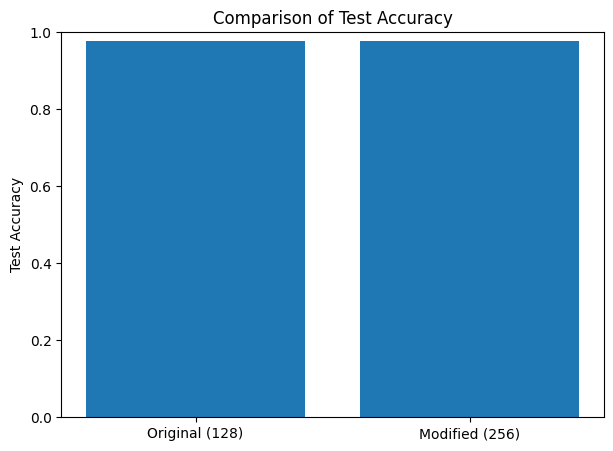

In [46]:
# Compare test accuracy

models_name = ["Original (128)", "Modified (256)"]
accuracies = [test_accuracy, exp_test_accuracy]

plt.figure(figsize=(7, 5))
plt.bar(models_name, accuracies)

plt.title("Comparison of Test Accuracy")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)

plt.show()

### Experiment Results and Analysis

The original model used 128 neurons in the hidden layer, while the modified model used 256 neurons.

The original model achieved a test accuracy of 97.82% with a test loss of 0.07389. After increasing the hidden layer to 256 neurons, the test accuracy increased to 98.07% and the test loss decreased to 0.06361.

This suggests that the modified model was able to learn slightly more useful patterns from the MNIST images. Increasing the number of neurons gives the hidden layer greater capacity to represent complex patterns. However, the improvement was relatively small, showing that the original 128-neuron model was already performing very well.

## Final Insights

### Key Findings

1. The MNIST dataset contains 28×28 grayscale images representing handwritten digits from 0 to 9.

2. The original neural network with 128 hidden neurons achieved a test accuracy of 97.82%, showing that a simple feedforward neural network can classify handwritten digits effectively.

3. The original model achieved a test loss of 0.07389 on the test dataset.

4. Increasing the number of hidden neurons from 128 to 256 improved the test accuracy from 97.82% to 98.07%.

5. The modified model also achieved a lower test loss of 0.06361 compared with 0.07389 for the original model.

6. The increase in hidden neurons provided the network with greater capacity to learn patterns, although the improvement in accuracy was relatively small.

## Limitations

1. The model uses a simple fully connected neural network and does not take advantage of the spatial structure of images.

2. The experiment changes only the number of neurons in the hidden layer, so other factors such as learning rate, batch size, or network depth were not investigated.

3. The model was trained only on the MNIST dataset, so its performance may not directly represent performance on more complex real-world handwritten images.

4. The model may have room for improvement compared with more advanced neural-network architectures designed specifically for image classification.

## Possible Improvement

A possible next step would be to use a Convolutional Neural Network (CNN). CNNs are designed to work with image data and can learn spatial features such as edges, shapes, and patterns more effectively than a simple fully connected network.

## Conclusion

In this project, a simple neural network was developed to classify handwritten digits from the MNIST dataset. The images were normalized and flattened before being provided to the network.

The original model used 128 neurons in its hidden layer and achieved a test accuracy of 97.82%. As an experiment, the hidden layer was increased to 256 neurons. The modified model achieved a test accuracy of 98.07% and a test loss of 0.06361.

The experiment showed that increasing the number of hidden neurons produced a small improvement in performance. Overall, the project demonstrated the basic workflow of preparing image data, building a neural network, training it, evaluating its performance, and experimenting with its architecture.